# Regex Summarizer Results Report

Comparing **String-based** vs **Regex-based** approaches for AWS, Azure and GCP policies.

In [28]:
import json
import pandas as pd
import numpy as np

# Load all result files
with open('results_aws/results_aws.json', 'r') as f:
    string_aws = json.load(f)

with open('results_aws/results_aws_regex_based.json', 'r') as f:
    regex_aws = json.load(f)

with open('string_results/results_azure.json', 'r') as f:
    string_azure = json.load(f)

with open('string_results/results_gcp.json', 'r') as f:
    string_gcp = json.load(f)

with open('regex_results/results_azure.json', 'r') as f:
    regex_azure = json.load(f)

with open('regex_results/results_gcp.json', 'r') as f:
    regex_gcp = json.load(f)

print(f"String-based AWS: {len(string_aws)} results")
print(f"Regex-based AWS: {len(regex_aws)} results")
print(f"String-based Azure: {len(string_azure)} results")
print(f"String-based GCP: {len(string_gcp)} results")
print(f"Regex-based Azure: {len(regex_azure)} results")
print(f"Regex-based GCP: {len(regex_gcp)} results")

String-based AWS: 587 results
Regex-based AWS: 587 results
String-based Azure: 100 results
String-based GCP: 100 results
Regex-based Azure: 100 results
Regex-based GCP: 100 results


In [29]:
# Define metrics to report
metrics = [
    'jaccard_similarity',
    'ops_regex_from_dfa',
    'ops_regex_from_llm',
    'length_regex_from_dfa',
    'length_regex_from_llm',
    'iteration',
    'solve_time_ms',
    'satisfiability',
    'count_time_ms'
]

def extract_metrics(data, approach_name):
    """Extract relevant metrics from result data."""
    rows = []
    for item in data:
        row = {
            'approach': approach_name,
            'cloud': item.get('cloud'),
            'file': item.get('file'),
        }
        for m in metrics:
            val = item.get(m)
            # Convert numeric strings to float
            if m != 'satisfiability' and val is not None:
                try:
                    row[m] = float(val)
                except (ValueError, TypeError):
                    row[m] = val
            else:
                row[m] = val
        rows.append(row)
    return pd.DataFrame(rows)

## AWS Results

In [30]:
# Create DataFrames for AWS
df_string_aws = extract_metrics(string_aws, 'string_based')
df_regex_aws = extract_metrics(regex_aws, 'regex_based')

df_aws = pd.concat([df_string_aws, df_regex_aws], ignore_index=True)

print("=" * 60)
print("AWS - String-based Approach Summary")
print("=" * 60)
display(df_string_aws[metrics].describe())

AWS - String-based Approach Summary


,jaccard_similarity,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm,iteration,solve_time_ms,count_time_ms
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,0.844652,765.490842,15.113553,861.703297,40.631868,1.987179,413.147550,5369.604433
std,0.337230,1426.199798,25.368440,1570.156978,47.163059,1.624870,1044.166441,17066.217812
min,0.000000,1.000000,1.000000,21.000000,2.000000,1.000000,3.904370,2.785090
25%,0.990000,190.000000,4.000000,211.000000,15.000000,1.000000,26.119400,14.555525
50%,1.000000,192.000000,4.000000,232.000000,23.000000,1.000000,68.806250,58.100050
75%,1.000000,196.000000,11.000000,245.000000,37.000000,2.000000,216.953750,201.701250
max,1.000000,8134.000000,270.000000,8894.000000,517.000000,5.000000,7171.830000,78206.400000


In [31]:
print("=" * 60)
print("AWS - Regex-based Approach Summary")
print("=" * 60)
display(df_regex_aws[metrics].describe())

AWS - Regex-based Approach Summary


,jaccard_similarity,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm,iteration,solve_time_ms,count_time_ms
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,0.921813,765.490842,10.080586,861.703297,29.935897,1.406593,392.332876,5356.137097
std,0.263472,1426.199798,38.341021,1570.156978,52.599068,1.160304,965.061078,17024.294142
min,0.000000,1.000000,1.000000,21.000000,2.000000,1.000000,3.803990,2.781170
25%,1.000000,190.000000,2.000000,211.000000,2.000000,1.000000,25.762300,14.510000
50%,1.000000,192.000000,4.000000,232.000000,23.000000,1.000000,69.728250,58.438500
75%,1.000000,196.000000,4.000000,245.000000,34.000000,1.000000,214.387750,198.060750
max,1.000000,8134.000000,855.000000,8894.000000,1041.000000,5.000000,7077.120000,68163.600000


In [32]:
# Side-by-side comparison for AWS
print("=" * 60)
print("AWS - Comparison (Mean Values)")
print("=" * 60)

numeric_metrics = [m for m in metrics if m != 'satisfiability']
comparison_aws = pd.DataFrame({
    'Metric': numeric_metrics,
    'String-based (mean)': [df_string_aws[m].mean() for m in numeric_metrics],
    'Regex-based (mean)': [df_regex_aws[m].mean() for m in numeric_metrics],
})
comparison_aws['Difference'] = comparison_aws['String-based (mean)'] - comparison_aws['Regex-based (mean)']
display(comparison_aws)

AWS - Comparison (Mean Values)


,Metric,String-based (mean),Regex-based (mean),Difference
0,jaccard_similarity,0.844652,0.921813,-0.077161
1,ops_regex_from_dfa,765.490842,765.490842,0.000000
2,ops_regex_from_llm,15.113553,10.080586,5.032967
3,length_regex_from_dfa,861.703297,861.703297,0.000000
4,length_regex_from_llm,40.631868,29.935897,10.695971
5,iteration,1.987179,1.406593,0.580586
6,solve_time_ms,413.147550,392.332876,20.814674
7,count_time_ms,5369.604433,5356.137097,13.467337


## Azure Results

In [33]:
# Create DataFrames for Azure
df_string_azure = extract_metrics(string_azure, 'string_based')
df_regex_azure = extract_metrics(regex_azure, 'regex_based')

# Combine for comparison
df_azure = pd.concat([df_string_azure, df_regex_azure], ignore_index=True)

print("=" * 60)
print("AZURE - String-based Approach Summary")
print("=" * 60)
display(df_string_azure[metrics].describe())

AZURE - String-based Approach Summary


,jaccard_similarity,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm,iteration,solve_time_ms,count_time_ms
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.930300,192.960000,4.690000,291.730000,84.850000,2.750000,712.717119,255.126892
std,0.255337,1.716939,1.268858,39.235331,38.262352,1.085953,1187.920512,255.404051
min,0.000000,192.000000,4.000000,227.000000,54.000000,2.000000,64.098300,15.352800
25%,1.000000,192.000000,4.000000,263.000000,54.000000,2.000000,195.767000,45.085450
50%,1.000000,192.000000,4.000000,263.000000,72.000000,2.000000,314.641000,170.212500
75%,1.000000,192.000000,4.000000,299.000000,90.000000,4.000000,687.173500,331.475750
max,1.000000,196.000000,7.000000,372.000000,163.000000,5.000000,7627.210000,1586.440000


In [34]:
print("=" * 60)
print("AZURE - Regex-based Approach Summary")
print("=" * 60)
display(df_regex_azure[metrics].describe())

AZURE - Regex-based Approach Summary


,jaccard_similarity,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm,iteration,solve_time_ms,count_time_ms
count,99.000000,99.000000,99.000000,99.000000,99.000000,100.000000,100.000000,100.000000
mean,0.989899,192.929293,8.797980,293.030303,89.565657,1.310000,715.550536,255.572604
std,0.100504,1.697853,27.796263,39.411087,52.758046,0.960797,1196.581049,254.869585
min,0.000000,192.000000,4.000000,227.000000,54.000000,1.000000,62.713000,16.305300
25%,1.000000,192.000000,4.000000,263.000000,54.000000,1.000000,196.544500,46.315875
50%,1.000000,192.000000,4.000000,263.000000,54.000000,1.000000,311.216500,174.507000
75%,1.000000,192.000000,5.500000,299.000000,97.000000,1.000000,682.229000,338.943500
max,1.000000,196.000000,206.000000,372.000000,356.000000,5.000000,7656.680000,1581.400000


In [35]:
# Side-by-side comparison for Azure
print("=" * 60)
print("AZURE - Comparison (Mean Values)")
print("=" * 60)

numeric_metrics = [m for m in metrics if m != 'satisfiability']
comparison_azure = pd.DataFrame({
    'Metric': numeric_metrics,
    'String-based (mean)': [df_string_azure[m].mean() for m in numeric_metrics],
    'Regex-based (mean)': [df_regex_azure[m].mean() for m in numeric_metrics],
})
comparison_azure['Difference'] = comparison_azure['String-based (mean)'] - comparison_azure['Regex-based (mean)']
display(comparison_azure)

AZURE - Comparison (Mean Values)


,Metric,String-based (mean),Regex-based (mean),Difference
0,jaccard_similarity,0.930300,0.989899,-0.059599
1,ops_regex_from_dfa,192.960000,192.929293,0.030707
2,ops_regex_from_llm,4.690000,8.797980,-4.107980
3,length_regex_from_dfa,291.730000,293.030303,-1.300303
4,length_regex_from_llm,84.850000,89.565657,-4.715657
5,iteration,2.750000,1.310000,1.440000
6,solve_time_ms,712.717119,715.550536,-2.833417
7,count_time_ms,255.126892,255.572604,-0.445712


## GCP Results

In [36]:
# Create DataFrames for GCP
df_string_gcp = extract_metrics(string_gcp, 'string_based')
df_regex_gcp = extract_metrics(regex_gcp, 'regex_based')

print("=" * 60)
print("GCP - String-based Approach Summary")
print("=" * 60)
display(df_string_gcp[metrics].describe())

GCP - String-based Approach Summary


,jaccard_similarity,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm,iteration,solve_time_ms,count_time_ms
count,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,0.92000,194.120000,5.710000,246.340000,33.180000,2.010000,2221.57353,130.303377
std,0.27266,2.006454,1.719144,24.221712,13.265266,1.424852,5817.39944,186.131182
min,0.00000,192.000000,4.000000,218.000000,9.000000,1.000000,25.79120,9.039840
25%,1.00000,192.000000,4.000000,230.000000,21.000000,1.000000,166.52225,36.181500
50%,1.00000,196.000000,7.000000,248.500000,39.000000,1.000000,390.27850,68.116900
75%,1.00000,196.000000,7.000000,254.000000,45.000000,3.000000,889.25950,116.544000
max,1.00000,196.000000,13.000000,363.000000,63.000000,5.000000,39432.80000,1042.310000


In [37]:
print("=" * 60)
print("GCP - Regex-based Approach Summary")
print("=" * 60)
display(df_regex_gcp[metrics].describe())

GCP - Regex-based Approach Summary


,jaccard_similarity,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm,iteration,solve_time_ms,count_time_ms
count,99.000000,99.000000,99.000000,99.000000,99.000000,100.000000,100.000000,100.000000
mean,0.950606,194.060606,5.727273,243.222222,32.979798,1.290000,2147.752227,129.687591
std,0.215486,2.009255,1.765995,15.184952,13.205580,1.007998,5461.300779,183.070487
min,0.000000,192.000000,4.000000,218.000000,9.000000,1.000000,24.042800,9.040250
25%,1.000000,192.000000,4.000000,230.000000,21.000000,1.000000,165.367750,35.879600
50%,1.000000,196.000000,7.000000,248.000000,39.000000,1.000000,387.298000,66.222700
75%,1.000000,196.000000,7.000000,254.000000,44.500000,1.000000,885.307000,114.413000
max,1.000000,196.000000,12.000000,299.000000,62.000000,5.000000,36402.200000,1013.730000


In [38]:
# Side-by-side comparison for GCP
print("=" * 60)
print("GCP - Comparison (Mean Values)")
print("=" * 60)

comparison_gcp = pd.DataFrame({
    'Metric': numeric_metrics,
    'String-based (mean)': [df_string_gcp[m].mean() for m in numeric_metrics],
    'Regex-based (mean)': [df_regex_gcp[m].mean() for m in numeric_metrics],
})
comparison_gcp['Difference'] = comparison_gcp['String-based (mean)'] - comparison_gcp['Regex-based (mean)']
display(comparison_gcp)

GCP - Comparison (Mean Values)


,Metric,String-based (mean),Regex-based (mean),Difference
0,jaccard_similarity,0.920000,0.950606,-0.030606
1,ops_regex_from_dfa,194.120000,194.060606,0.059394
2,ops_regex_from_llm,5.710000,5.727273,-0.017273
3,length_regex_from_dfa,246.340000,243.222222,3.117778
4,length_regex_from_llm,33.180000,32.979798,0.200202
5,iteration,2.010000,1.290000,0.720000
6,solve_time_ms,2221.573530,2147.752227,73.821303
7,count_time_ms,130.303377,129.687591,0.615786


## Overall Summary

In [39]:
# Combined summary table
print("=" * 80)
print("OVERALL SUMMARY")
print("=" * 80)

summary_data = {
    'Cloud': ['Azure', 'Azure', 'GCP', 'GCP'],
    'Approach': ['String-based', 'Regex-based', 'String-based', 'Regex-based'],
    'Count': [len(string_azure), len(regex_azure), len(string_gcp), len(regex_gcp)],
    'Avg Jaccard': [
        df_string_azure['jaccard_similarity'].mean(),
        df_regex_azure['jaccard_similarity'].mean(),
        df_string_gcp['jaccard_similarity'].mean(),
        df_regex_gcp['jaccard_similarity'].mean()
    ],
    'Avg Iterations': [
        df_string_azure['iteration'].mean(),
        df_regex_azure['iteration'].mean(),
        df_string_gcp['iteration'].mean(),
        df_regex_gcp['iteration'].mean()
    ],
    'Avg Solve Time (ms)': [
        df_string_azure['solve_time_ms'].mean(),
        df_regex_azure['solve_time_ms'].mean(),
        df_string_gcp['solve_time_ms'].mean(),
        df_regex_gcp['solve_time_ms'].mean()
    ],
    'Avg Count Time (ms)': [
        df_string_azure['count_time_ms'].mean(),
        df_regex_azure['count_time_ms'].mean(),
        df_string_gcp['count_time_ms'].mean(),
        df_regex_gcp['count_time_ms'].mean()
    ],
    'Avg DFA Ops': [
        df_string_azure['ops_regex_from_dfa'].mean(),
        df_regex_azure['ops_regex_from_dfa'].mean(),
        df_string_gcp['ops_regex_from_dfa'].mean(),
        df_regex_gcp['ops_regex_from_dfa'].mean()
    ],
    'Avg LLM Ops': [
        df_string_azure['ops_regex_from_llm'].mean(),
        df_regex_azure['ops_regex_from_llm'].mean(),
        df_string_gcp['ops_regex_from_llm'].mean(),
        df_regex_gcp['ops_regex_from_llm'].mean()
    ],
    'Avg DFA Length': [
        df_string_azure['length_regex_from_dfa'].mean(),
        df_regex_azure['length_regex_from_dfa'].mean(),
        df_string_gcp['length_regex_from_dfa'].mean(),
        df_regex_gcp['length_regex_from_dfa'].mean()
    ],
    'Avg LLM Length': [
        df_string_azure['length_regex_from_llm'].mean(),
        df_regex_azure['length_regex_from_llm'].mean(),
        df_string_gcp['length_regex_from_llm'].mean(),
        df_regex_gcp['length_regex_from_llm'].mean()
    ],
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

OVERALL SUMMARY


,Cloud,Approach,Count,Avg Jaccard,Avg Iterations,Avg Solve Time (ms),Avg Count Time (ms),Avg DFA Ops,Avg LLM Ops,Avg DFA Length,Avg LLM Length
0,Azure,String-based,100,0.930300,2.75,712.717119,255.126892,192.960000,4.690000,291.730000,84.850000
1,Azure,Regex-based,100,0.989899,1.31,715.550536,255.572604,192.929293,8.797980,293.030303,89.565657
2,GCP,String-based,100,0.920000,2.01,2221.573530,130.303377,194.120000,5.710000,246.340000,33.180000
3,GCP,Regex-based,100,0.950606,1.29,2147.752227,129.687591,194.060606,5.727273,243.222222,32.979798


In [40]:
# Compression ratio analysis
print("=" * 80)
print("COMPRESSION RATIO (DFA Length / LLM Length)")
print("=" * 80)

df_string_azure['compression_ratio'] = df_string_azure['length_regex_from_dfa'] / df_string_azure['length_regex_from_llm']
df_regex_azure['compression_ratio'] = df_regex_azure['length_regex_from_dfa'] / df_regex_azure['length_regex_from_llm']
df_string_gcp['compression_ratio'] = df_string_gcp['length_regex_from_dfa'] / df_string_gcp['length_regex_from_llm']
df_regex_gcp['compression_ratio'] = df_regex_gcp['length_regex_from_dfa'] / df_regex_gcp['length_regex_from_llm']

compression_summary = pd.DataFrame({
    'Cloud': ['Azure', 'Azure', 'GCP', 'GCP'],
    'Approach': ['String-based', 'Regex-based', 'String-based', 'Regex-based'],
    'Avg Compression Ratio': [
        df_string_azure['compression_ratio'].mean(),
        df_regex_azure['compression_ratio'].mean(),
        df_string_gcp['compression_ratio'].mean(),
        df_regex_gcp['compression_ratio'].mean()
    ],
    'Min Compression Ratio': [
        df_string_azure['compression_ratio'].min(),
        df_regex_azure['compression_ratio'].min(),
        df_string_gcp['compression_ratio'].min(),
        df_regex_gcp['compression_ratio'].min()
    ],
    'Max Compression Ratio': [
        df_string_azure['compression_ratio'].max(),
        df_regex_azure['compression_ratio'].max(),
        df_string_gcp['compression_ratio'].max(),
        df_regex_gcp['compression_ratio'].max()
    ],
})
display(compression_summary)

COMPRESSION RATIO (DFA Length / LLM Length)


,Cloud,Approach,Avg Compression Ratio,Min Compression Ratio,Max Compression Ratio
0,Azure,String-based,3.877820,1.487013,4.870370
1,Azure,Regex-based,3.864041,0.918495,4.870370
2,GCP,String-based,8.933038,4.047619,24.222222
3,GCP,Regex-based,8.863548,4.177419,24.222222


In [41]:
# Operations reduction analysis
print("=" * 80)
print("OPERATIONS REDUCTION (DFA Ops / LLM Ops)")
print("=" * 80)

df_string_azure['ops_ratio'] = df_string_azure['ops_regex_from_dfa'] / df_string_azure['ops_regex_from_llm']
df_regex_azure['ops_ratio'] = df_regex_azure['ops_regex_from_dfa'] / df_regex_azure['ops_regex_from_llm']
df_string_gcp['ops_ratio'] = df_string_gcp['ops_regex_from_dfa'] / df_string_gcp['ops_regex_from_llm']
df_regex_gcp['ops_ratio'] = df_regex_gcp['ops_regex_from_dfa'] / df_regex_gcp['ops_regex_from_llm']

ops_summary = pd.DataFrame({
    'Cloud': ['Azure', 'Azure', 'GCP', 'GCP'],
    'Approach': ['String-based', 'Regex-based', 'String-based', 'Regex-based'],
    'Avg Ops Reduction': [
        df_string_azure['ops_ratio'].mean(),
        df_regex_azure['ops_ratio'].mean(),
        df_string_gcp['ops_ratio'].mean(),
        df_regex_gcp['ops_ratio'].mean()
    ],
})
display(ops_summary)

OPERATIONS REDUCTION (DFA Ops / LLM Ops)


,Cloud,Approach,Avg Ops Reduction
0,Azure,String-based,43.422857
1,Azure,Regex-based,42.094447
2,GCP,String-based,36.985341
3,GCP,Regex-based,36.978114


## Sample Results (First 5)

In [42]:
# Show first 5 results from each dataset
display_cols = ['file', 'jaccard_similarity', 'iteration', 'solve_time_ms', 'count_time_ms', 
                'ops_regex_from_dfa', 'ops_regex_from_llm', 'length_regex_from_dfa', 'length_regex_from_llm']

print("String-based Azure (first 5):")
display(df_string_azure[display_cols].head())

print("\nRegex-based Azure (first 5):")
display(df_regex_azure[display_cols].head())

String-based Azure (first 5):


,file,jaccard_similarity,iteration,solve_time_ms,count_time_ms,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm
0,as0.json,1.00,2.0,80.4829,18.9932,192.0,4.0,294.0,85.0
1,as1.json,1.00,4.0,267.0980,158.8650,192.0,4.0,263.0,54.0
2,as2.json,0.01,5.0,141.3940,29.5952,196.0,4.0,355.0,142.0
3,as3.json,1.00,4.0,173.5230,33.6361,196.0,7.0,351.0,142.0
4,as4.json,1.00,4.0,158.4260,32.4253,196.0,7.0,361.0,152.0



Regex-based Azure (first 5):


,file,jaccard_similarity,iteration,solve_time_ms,count_time_ms,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm
0,as0.json,1.0,1.0,86.7629,19.4170,192.0,4.0,294.0,85.0
1,as1.json,1.0,1.0,263.5080,158.1380,192.0,4.0,263.0,54.0
2,as2.json,1.0,1.0,142.7280,29.5194,196.0,7.0,355.0,146.0
3,as3.json,1.0,1.0,174.8610,34.4931,196.0,7.0,351.0,142.0
4,as4.json,1.0,1.0,156.1190,32.6557,196.0,7.0,361.0,152.0


In [43]:
print("String-based GCP (first 5):")
display(df_string_gcp[display_cols].head())

print("\nRegex-based GCP (first 5):")
display(df_regex_gcp[display_cols].head())

String-based GCP (first 5):


,file,jaccard_similarity,iteration,solve_time_ms,count_time_ms,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm
0,bd0.json,1.0,1.0,109.6180,25.5608,196.0,7.0,248.0,39.0
1,bd1.json,1.0,2.0,86.2396,20.7495,196.0,7.0,256.0,47.0
2,bd2.json,1.0,2.0,274.5630,37.7302,196.0,7.0,248.0,39.0
3,bd3.json,1.0,3.0,69.9512,20.6161,196.0,7.0,254.0,45.0
4,bd4.json,1.0,1.0,107.0130,21.5031,196.0,7.0,251.0,42.0



Regex-based GCP (first 5):


,file,jaccard_similarity,iteration,solve_time_ms,count_time_ms,ops_regex_from_dfa,ops_regex_from_llm,length_regex_from_dfa,length_regex_from_llm
0,bd0.json,1.0,1.0,117.5960,24.2416,196.0,7.0,248.0,39.0
1,bd1.json,1.0,1.0,84.6478,21.2968,196.0,7.0,256.0,47.0
2,bd2.json,1.0,1.0,272.5390,38.1000,196.0,7.0,248.0,39.0
3,bd3.json,1.0,1.0,73.4147,21.1811,196.0,7.0,254.0,45.0
4,bd4.json,1.0,1.0,112.5390,21.9502,196.0,7.0,251.0,42.0


## Distribution and Null Analysis

In [44]:
print("=" * 80)
print("NULL / MISSING VALUES ANALYSIS")
print("=" * 80)

all_dfs = {
    'AWS String-based': df_string_aws,
    'AWS Regex-based': df_regex_aws,
    'Azure String-based': df_string_azure,
    'Azure Regex-based': df_regex_azure,
    'GCP String-based': df_string_gcp,
    'GCP Regex-based': df_regex_gcp,
}

null_rows = []
for name, df in all_dfs.items():
    total = len(df)
    row = {'Dataset': name, 'Total Policies': total}
    for m in metrics:
        null_count = df[m].isna().sum()
        row[f'{m} (nulls)'] = null_count
        row[f'{m} (null %)'] = round(100 * null_count / total, 1) if total > 0 else 0
    null_rows.append(row)

df_nulls = pd.DataFrame(null_rows)

# Display null counts
null_count_cols = ['Dataset', 'Total Policies'] + [f'{m} (nulls)' for m in metrics]
print("\nNull Counts:")
display(df_nulls[null_count_cols])

# Display null percentages
null_pct_cols = ['Dataset', 'Total Policies'] + [f'{m} (null %)' for m in metrics]
print("\nNull Percentages:")
display(df_nulls[null_pct_cols])

NULL / MISSING VALUES ANALYSIS

Null Counts:


,Dataset,Total Policies,jaccard_similarity (nulls),ops_regex_from_dfa (nulls),ops_regex_from_llm (nulls),length_regex_from_dfa (nulls),length_regex_from_llm (nulls),iteration (nulls),solve_time_ms (nulls),satisfiability (nulls),count_time_ms (nulls)
0,AWS String-based,587,41,41,41,41,41,41,41,0,41
1,AWS Regex-based,587,41,41,41,41,41,41,41,0,41
2,Azure String-based,100,0,0,0,0,0,0,0,0,0
3,Azure Regex-based,100,1,1,1,1,1,0,0,0,0
4,GCP String-based,100,0,0,0,0,0,0,0,0,0
5,GCP Regex-based,100,1,1,1,1,1,0,0,0,0



Null Percentages:


,Dataset,Total Policies,jaccard_similarity (null %),ops_regex_from_dfa (null %),ops_regex_from_llm (null %),length_regex_from_dfa (null %),length_regex_from_llm (null %),iteration (null %),solve_time_ms (null %),satisfiability (null %),count_time_ms (null %)
0,AWS String-based,587,7.0,7.0,7.0,7.0,7.0,7.0,7.0,0.0,7.0
1,AWS Regex-based,587,7.0,7.0,7.0,7.0,7.0,7.0,7.0,0.0,7.0
2,Azure String-based,100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Azure Regex-based,100,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,GCP String-based,100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,GCP Regex-based,100,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0


In [45]:
print("=" * 80)
print("SATISFIABILITY DISTRIBUTION")
print("=" * 80)

sat_rows = []
for name, df in all_dfs.items():
    total = len(df)
    sat_counts = df['satisfiability'].value_counts()
    row = {'Dataset': name, 'Total': total}
    for val in ['sat', 'unsat']:
        count = sat_counts.get(val, 0)
        row[val] = count
        row[f'{val} (%)'] = round(100 * count / total, 1) if total > 0 else 0

    null_sat = df['satisfiability'].isna().sum()
    row['unknown/null'] = null_sat
    row['unknown/null (%)'] = round(100 * null_sat / total, 1) if total > 0 else 0
    sat_rows.append(row)

df_sat = pd.DataFrame(sat_rows)
display(df_sat)

SATISFIABILITY DISTRIBUTION


,Dataset,Total,sat,sat (%),unsat,unsat (%),unknown/null,unknown/null (%)
0,AWS String-based,587,546,93.0,41,7.0,0,0.0
1,AWS Regex-based,587,546,93.0,41,7.0,0,0.0
2,Azure String-based,100,100,100.0,0,0.0,0,0.0
3,Azure Regex-based,100,100,100.0,0,0.0,0,0.0
4,GCP String-based,100,100,100.0,0,0.0,0,0.0
5,GCP Regex-based,100,100,100.0,0,0.0,0,0.0


In [46]:
print("=" * 80)
print("JACCARD SIMILARITY DISTRIBUTION")
print("=" * 80)

jaccard_bins = [0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
jaccard_labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-0.9', '0.9-0.95', '0.95-1.0']

dist_rows = []
for name, df in all_dfs.items():
    valid = df['jaccard_similarity'].dropna()
    binned = pd.cut(valid, bins=jaccard_bins, labels=jaccard_labels, include_lowest=True)
    counts = binned.value_counts().sort_index()
    row = {'Dataset': name, 'Total (non-null)': len(valid)}
    row['Perfect (=1.0)'] = int((valid == 1.0).sum())
    row['Zero (=0.0)'] = int((valid == 0.0).sum())
    for label in jaccard_labels:
        row[label] = counts.get(label, 0)
    dist_rows.append(row)

df_dist = pd.DataFrame(dist_rows)
print("\nJaccard Similarity Bin Counts:")
display(df_dist)

print("\nPerfect Score (Jaccard = 1.0) Rates:")
for name, df in all_dfs.items():
    valid = df['jaccard_similarity'].dropna()
    perfect = (valid == 1.0).sum()
    print(f"  {name}: {perfect}/{len(valid)} ({100*perfect/len(valid):.1f}%)")

JACCARD SIMILARITY DISTRIBUTION

Jaccard Similarity Bin Counts:


,Dataset,Total (non-null),Perfect (=1.0),Zero (=0.0),0-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-0.9,0.9-0.95,0.95-1.0
0,AWS String-based,546,392,50,69,6,8,24,1,4,434
1,AWS Regex-based,546,497,27,41,2,0,2,1,0,500
2,Azure String-based,100,93,4,7,0,0,0,0,0,93
3,Azure Regex-based,99,98,1,1,0,0,0,0,0,98
4,GCP String-based,100,92,8,8,0,0,0,0,0,92
5,GCP Regex-based,99,94,4,5,0,0,0,0,0,94



Perfect Score (Jaccard = 1.0) Rates:
  AWS String-based: 392/546 (71.8%)
  AWS Regex-based: 497/546 (91.0%)
  Azure String-based: 93/100 (93.0%)
  Azure Regex-based: 98/99 (99.0%)
  GCP String-based: 92/100 (92.0%)
  GCP Regex-based: 94/99 (94.9%)


In [47]:
print("=" * 80)
print("ITERATION DISTRIBUTION")
print("=" * 80)

for name, df in all_dfs.items():
    valid = df['iteration'].dropna()
    print(f"\n{name}:")
    iter_counts = valid.value_counts().sort_index()
    for it, count in iter_counts.items():
        print(f"  Iteration {int(it)}: {count} ({100*count/len(valid):.1f}%)")

print("\n")
print("=" * 80)
print("ERROR / FAILURE ANALYSIS")
print("=" * 80)

# Check for entries with null jaccard but non-null satisfiability (failed comparisons)
for name, df in all_dfs.items():
    total = len(df)
    null_jaccard = df['jaccard_similarity'].isna().sum()
    sat_but_null_jaccard = ((df['satisfiability'] == 'sat') & df['jaccard_similarity'].isna()).sum()
    unsat = (df['satisfiability'] == 'unsat').sum()
    print(f"\n{name} ({total} total):")
    print(f"  Unsatisfiable (unsat): {unsat} ({100*unsat/total:.1f}%)")
    print(f"  Missing Jaccard score: {null_jaccard} ({100*null_jaccard/total:.1f}%)")
    print(f"  Satisfiable but missing Jaccard (errors): {sat_but_null_jaccard}")

ITERATION DISTRIBUTION

AWS String-based:
  Iteration 1: 377 (69.0%)
  Iteration 2: 33 (6.0%)
  Iteration 3: 14 (2.6%)
  Iteration 4: 10 (1.8%)
  Iteration 5: 112 (20.5%)

AWS Regex-based:
  Iteration 1: 481 (88.1%)
  Iteration 2: 5 (0.9%)
  Iteration 3: 10 (1.8%)
  Iteration 4: 3 (0.5%)
  Iteration 5: 47 (8.6%)

Azure String-based:
  Iteration 2: 65 (65.0%)
  Iteration 3: 4 (4.0%)
  Iteration 4: 22 (22.0%)
  Iteration 5: 9 (9.0%)

Azure Regex-based:
  Iteration 1: 89 (89.0%)
  Iteration 2: 1 (1.0%)
  Iteration 3: 5 (5.0%)
  Iteration 5: 5 (5.0%)

GCP String-based:
  Iteration 1: 57 (57.0%)
  Iteration 2: 14 (14.0%)
  Iteration 3: 14 (14.0%)
  Iteration 4: 1 (1.0%)
  Iteration 5: 14 (14.0%)

GCP Regex-based:
  Iteration 1: 92 (92.0%)
  Iteration 3: 1 (1.0%)
  Iteration 4: 1 (1.0%)
  Iteration 5: 6 (6.0%)


ERROR / FAILURE ANALYSIS

AWS String-based (587 total):
  Unsatisfiable (unsat): 41 (7.0%)
  Missing Jaccard score: 41 (7.0%)
  Satisfiable but missing Jaccard (errors): 0

AWS Regex

## Accuracy Analysis (Satisfiable Policies Only)

In [53]:
print("=" * 80)
print("ACCURACY ANALYSIS (SAT POLICIES ONLY - excluding unsat)")
print("=" * 80)

accuracy_rows = []
for name, df in all_dfs.items():
    # Filter to only satisfiable policies with a valid jaccard score
    sat_df = df[(df['satisfiability'] == 'sat') & df['jaccard_similarity'].notna()]
    total_sat = len(sat_df)
    
    if total_sat == 0:
        accuracy_rows.append({'Dataset': name, 'Sat Policies': 0})
        continue
    
    avg_jaccard = sat_df['jaccard_similarity'].mean()
    median_jaccard = sat_df['jaccard_similarity'].median()
    std_jaccard = sat_df['jaccard_similarity'].std()
    min_jaccard = sat_df['jaccard_similarity'].min()
    perfect = (sat_df['jaccard_similarity'] == 1.0).sum()
    above_90 = (sat_df['jaccard_similarity'] >= 0.9).sum()
    above_80 = (sat_df['jaccard_similarity'] >= 0.8).sum()
    below_50 = (sat_df['jaccard_similarity'] < 0.5).sum()
    zero = (sat_df['jaccard_similarity'] == 0.0).sum()
    
    accuracy_rows.append({
        'Dataset': name,
        'Sat Policies': total_sat,
        'Avg Jaccard': round(avg_jaccard, 4),
        'Median Jaccard': round(median_jaccard, 4),
        'Std Jaccard': round(std_jaccard, 4),
        'Min Jaccard': round(min_jaccard, 4),
        'Perfect (=1.0)': perfect,
        'Perfect (%)': round(100 * perfect / total_sat, 1),
        '>=0.9': above_90,
        '>=0.9 (%)': round(100 * above_90 / total_sat, 1),
        '>=0.8': above_80,
        '>=0.8 (%)': round(100 * above_80 / total_sat, 1),
        '<0.5': below_50,
        '<0.5 (%)': round(100 * below_50 / total_sat, 1),
        'Zero (=0.0)': zero,
    })

df_accuracy = pd.DataFrame(accuracy_rows)
display(df_accuracy)

ACCURACY ANALYSIS (SAT POLICIES ONLY - excluding unsat)


,Dataset,Sat Policies,Avg Jaccard,Median Jaccard,Std Jaccard,Min Jaccard,Perfect (=1.0),Perfect (%),>=0.9,>=0.9 (%),>=0.8,>=0.8 (%),<0.5,<0.5 (%),Zero (=0.0)
0,AWS String-based,546,0.8447,1.0,0.3372,0.0,392,71.8,439,80.4,439,80.4,80,14.7,50
1,AWS Regex-based,546,0.9218,1.0,0.2635,0.0,497,91.0,500,91.6,501,91.8,43,7.9,27
2,Azure String-based,100,0.9303,1.0,0.2553,0.0,93,93.0,93,93.0,93,93.0,7,7.0,4
3,Azure Regex-based,99,0.9899,1.0,0.1005,0.0,98,99.0,98,99.0,98,99.0,1,1.0,1
4,GCP String-based,100,0.9200,1.0,0.2727,0.0,92,92.0,92,92.0,92,92.0,8,8.0,8
5,GCP Regex-based,99,0.9506,1.0,0.2155,0.0,94,94.9,94,94.9,94,94.9,5,5.1,4


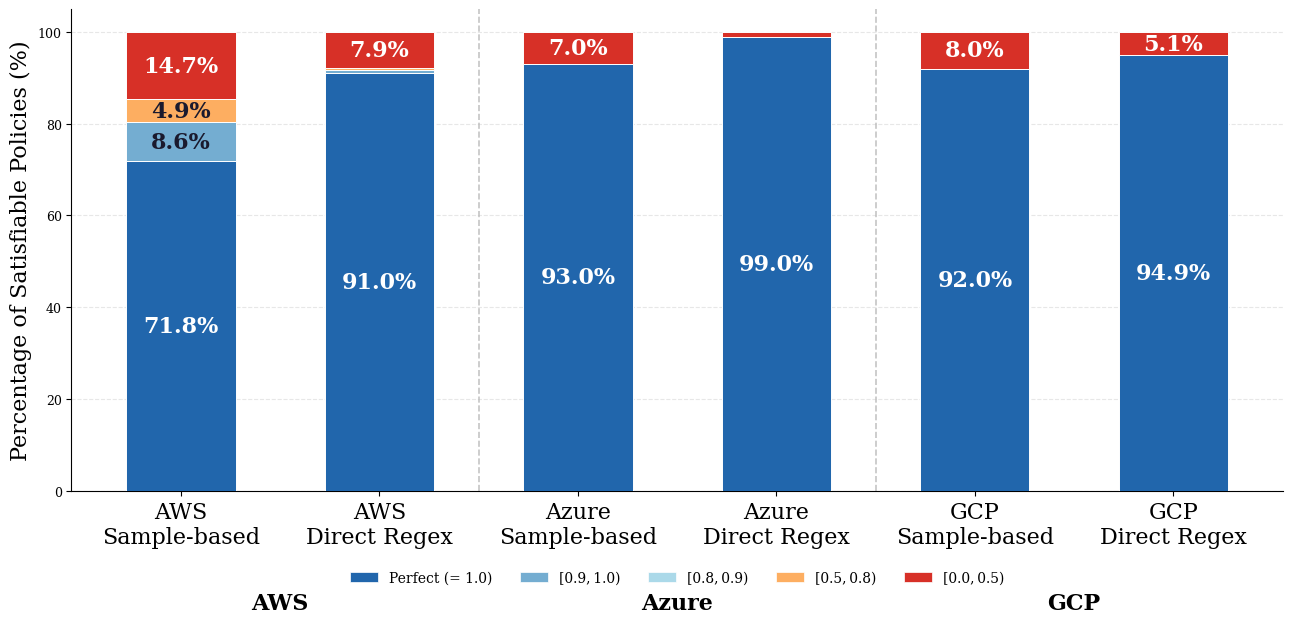

Chart saved to 'jaccard_quality_distribution.png'


In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Quality bands (RdYlBu ColorBrewer — colorblind-safe, print-safe) ---
perfect_pct  = df_accuracy['Perfect (%)'].values.astype(float)
above_90_pct = df_accuracy['>=0.9 (%)'].values.astype(float)
above_80_pct = df_accuracy['>=0.8 (%)'].values.astype(float)
below_50_pct = df_accuracy['<0.5 (%)'].values.astype(float)

band_perfect = perfect_pct
band_09_10   = above_90_pct - perfect_pct
band_08_09   = above_80_pct - above_90_pct
band_05_08   = 100 - above_80_pct - below_50_pct
band_00_05   = below_50_pct

BAND_DEFS = [
    ('Perfect (= 1.0)',  band_perfect, '#2166ac'),
    ('[0.9,\u20091.0)', band_09_10,   '#74add1'),
    ('[0.8,\u20090.9)', band_08_09,   '#abd9e9'),
    ('[0.5,\u20090.8)', band_05_08,   '#fdae61'),
    ('[0.0,\u20090.5)', band_00_05,   '#d73027'),
]

short_labels = [
    'AWS\nSample-based', 'AWS\nDirect Regex',
    'Azure\nSample-based', 'Azure\nDirect Regex',
    'GCP\nSample-based', 'GCP\nDirect Regex',
]

fig, ax = plt.subplots(figsize=(13, 7))
x      = np.arange(len(short_labels))
width  = 0.55
bottom = np.zeros(len(short_labels))

for band_label, values, color in BAND_DEFS:
    ax.bar(x, values, width, bottom=bottom,
           color=color, edgecolor='white', linewidth=0.7, zorder=3)
    dark = color in {'#2166ac', '#d73027'}
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val >= 2.5:
            ax.text(x[i], bot + val / 2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=16,
                    color='white' if dark else '#1a1a2e',
                    fontweight='bold', zorder=4)
    bottom += values

# --- Cloud provider group separators ---
for sep in [1.5, 3.5]:
    ax.axvline(sep, color='#bbb', linestyle='--', linewidth=1.2, alpha=0.85)

# --- Cloud provider labels below x-axis ticks ---
trans = ax.get_xaxis_transform()
for cloud, cx in [('AWS', 0.5), ('Azure', 2.5), ('GCP', 4.5)]:
    ax.text(cx, -0.21, cloud, transform=trans, ha='center', va='top',
            fontsize=16, fontweight='bold', color='black')

# --- Axes styling ---
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=16)
ax.set_ylim(0, 105)
ax.set_ylabel('Percentage of Satisfiable Policies (%)', fontsize=16)
ax.yaxis.grid(True, alpha=0.3, linestyle='--', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# --- Legend: horizontal row below the chart ---
band_handles = [
    mpatches.Patch(facecolor=c, edgecolor='white', linewidth=0.5, label=lbl)
    for lbl, _, c in BAND_DEFS
]
ax.legend(handles=band_handles,
          fontsize=10, ncol=5,
          loc='upper center', bbox_to_anchor=(0.5, -0.14),
          framealpha=0.95, edgecolor='None', fancybox=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('jaccard_quality_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved to 'jaccard_quality_distribution.png'")

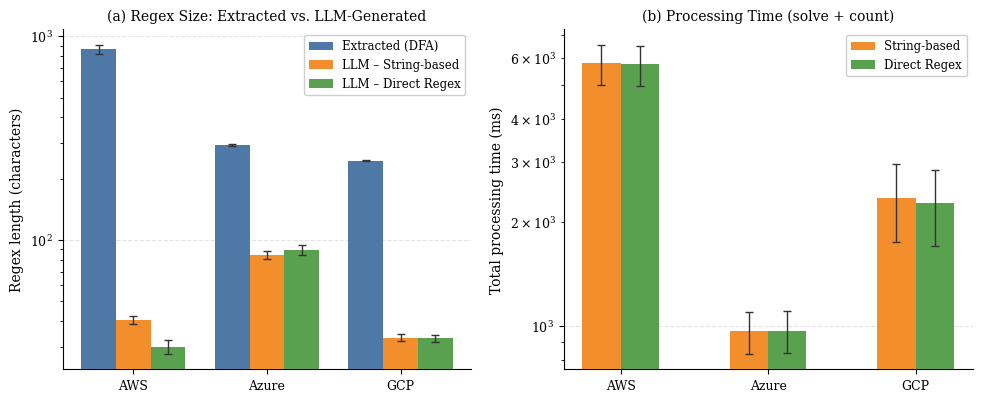

Saved → figure_regex_and_time.pdf  /  figure_regex_and_time.png


In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Publication style (ICLR-ready) ─────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'serif',
    'font.size':        9,
    'axes.labelsize':  10,
    'axes.titlesize':  10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  8.5,
    'pdf.fonttype':    42,   # embeds TrueType fonts in camera-ready PDFs
})


def _mean_sem(series):
    """Return (mean, standard-error-of-mean) ignoring NaNs."""
    v = series.dropna()
    return v.mean(), v.std() / np.sqrt(len(v))


clouds = ['AWS', 'Azure', 'GCP']
x      = np.arange(len(clouds))
w      = 0.26
BAR_KW = dict(edgecolor='none', linewidth=0, zorder=3)
ERR_KW = dict(fmt='none', elinewidth=1.0, capsize=3, capthick=1.0,
              ecolor='#333', zorder=4)

# ── Tableau-10 colours (colorblind-safe) ────────────────────────────────────
C_DFA = '#4e79a7'   # steel-blue  – extracted (DFA)
C_STR = '#f28e2b'   # orange      – string-based LLM
C_DIR = '#59a14f'   # green       – direct regex LLM

# ── Regex-length data (mean ± SEM) ──────────────────────────────────────────
dfa_pools = [
    pd.concat([df_string_aws['length_regex_from_dfa'],   df_regex_aws['length_regex_from_dfa']]),
    pd.concat([df_string_azure['length_regex_from_dfa'], df_regex_azure['length_regex_from_dfa']]),
    pd.concat([df_string_gcp['length_regex_from_dfa'],   df_regex_gcp['length_regex_from_dfa']]),
]
dfa_m,  dfa_e  = zip(*[_mean_sem(s) for s in dfa_pools])
str_lm, str_le = zip(*[_mean_sem(df['length_regex_from_llm'])
                        for df in [df_string_aws, df_string_azure, df_string_gcp]])
dir_lm, dir_le = zip(*[_mean_sem(df['length_regex_from_llm'])
                        for df in [df_regex_aws, df_regex_azure, df_regex_gcp]])

# ── Total-time data: solve_time_ms + count_time_ms (mean ± SEM) ─────────────
str_total = [df['solve_time_ms'].add(df['count_time_ms'])
             for df in [df_string_aws, df_string_azure, df_string_gcp]]
dir_total = [df['solve_time_ms'].add(df['count_time_ms'])
             for df in [df_regex_aws, df_regex_azure, df_regex_gcp]]

str_tm, str_te = zip(*[_mean_sem(s) for s in str_total])
dir_tm, dir_te = zip(*[_mean_sem(s) for s in dir_total])

# ── Figure ───────────────────────────────────────────────────────────────────
fig, (ax_size, ax_time) = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel (a): Regex sizes ───────────────────────────────────────────────────
ax_size.bar(x - w, dfa_m,  w, color=C_DFA, **BAR_KW, label='Extracted (DFA)')
ax_size.bar(x,     str_lm, w, color=C_STR, **BAR_KW, label='LLM – String-based')
ax_size.bar(x + w, dir_lm, w, color=C_DIR, **BAR_KW, label='LLM – Direct Regex')
ax_size.errorbar(x - w, dfa_m,  yerr=dfa_e,  **ERR_KW)
ax_size.errorbar(x,     str_lm, yerr=str_le, **ERR_KW)
ax_size.errorbar(x + w, dir_lm, yerr=dir_le, **ERR_KW)

ax_size.set_yscale('log')
ax_size.set_xticks(x)
ax_size.set_xticklabels(clouds)
ax_size.set_ylabel('Regex length (characters)')
ax_size.set_title('(a) Regex Size: Extracted vs. LLM-Generated')
ax_size.yaxis.grid(True, alpha=0.35, linestyle='--', which='major')
ax_size.set_axisbelow(True)
ax_size.spines[['top', 'right']].set_visible(False)
ax_size.legend(framealpha=0.95, edgecolor='#ccc', loc='upper right')

# ── Panel (b): Total processing time ────────────────────────────────────────
ax_time.bar(x - w / 2, str_tm, w, color=C_STR, **BAR_KW, label='String-based')
ax_time.bar(x + w / 2, dir_tm, w, color=C_DIR, **BAR_KW, label='Direct Regex')
ax_time.errorbar(x - w / 2, str_tm, yerr=str_te, **ERR_KW)
ax_time.errorbar(x + w / 2, dir_tm, yerr=dir_te, **ERR_KW)

ax_time.set_yscale('log')
ax_time.set_xticks(x)
ax_time.set_xticklabels(clouds)
ax_time.set_ylabel('Total processing time (ms)')
ax_time.set_title('(b) Processing Time (solve + count)')
ax_time.yaxis.grid(True, alpha=0.35, linestyle='--', which='major')
ax_time.set_axisbelow(True)
ax_time.spines[['top', 'right']].set_visible(False)
ax_time.legend(framealpha=0.95, edgecolor='#ccc')

plt.tight_layout(pad=1.5)
fig.savefig('figure_regex_and_time.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figure_regex_and_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → figure_regex_and_time.pdf  /  figure_regex_and_time.png")


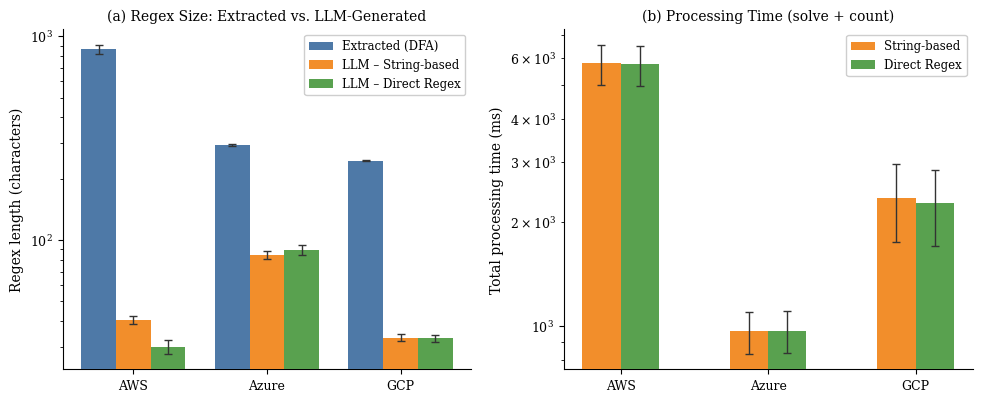

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Publication style (ICLR-ready) ─────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'serif',
    'font.size':        9,
    'axes.labelsize':  10,
    'axes.titlesize':  10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  8.5,
    'pdf.fonttype':    42,   # embeds TrueType fonts in camera-ready PDFs
})


def _mean_sem(series):
    """Return (mean, standard-error-of-mean) ignoring NaNs."""
    v = series.dropna()
    return v.mean(), v.std() / np.sqrt(len(v))


clouds = ['AWS', 'Azure', 'GCP']
x      = np.arange(len(clouds))
w      = 0.26
BAR_KW = dict(edgecolor='none', linewidth=0, zorder=3)
ERR_KW = dict(fmt='none', elinewidth=1.0, capsize=3, capthick=1.0,
              ecolor='#333', zorder=4)

# ── Tableau-10 colours (colorblind-safe) ────────────────────────────────────
C_DFA = '#4e79a7'   # steel-blue  – extracted (DFA)
C_STR = '#f28e2b'   # orange      – string-based LLM
C_DIR = '#59a14f'   # green       – direct regex LLM

# ── Regex-length data (mean ± SEM) ──────────────────────────────────────────
# DFA regex is the same ground-truth; pool both approaches per cloud
dfa_pools = [
    pd.concat([df_string_aws['length_regex_from_dfa'],   df_regex_aws['length_regex_from_dfa']]),
    pd.concat([df_string_azure['length_regex_from_dfa'], df_regex_azure['length_regex_from_dfa']]),
    pd.concat([df_string_gcp['length_regex_from_dfa'],   df_regex_gcp['length_regex_from_dfa']]),
]
dfa_m,  dfa_e  = zip(*[_mean_sem(s) for s in dfa_pools])
str_lm, str_le = zip(*[_mean_sem(df['length_regex_from_llm'])
                        for df in [df_string_aws, df_string_azure, df_string_gcp]])
dir_lm, dir_le = zip(*[_mean_sem(df['length_regex_from_llm'])
                        for df in [df_regex_aws, df_regex_azure, df_regex_gcp]])

# ── Total-time data: solve_time_ms + count_time_ms (mean ± SEM) ─────────────
str_total = [df['solve_time_ms'].add(df['count_time_ms'])
             for df in [df_string_aws, df_string_azure, df_string_gcp]]
dir_total = [df['solve_time_ms'].add(df['count_time_ms'])
             for df in [df_regex_aws, df_regex_azure, df_regex_gcp]]

str_tm, str_te = zip(*[_mean_sem(s) for s in str_total])
dir_tm, dir_te = zip(*[_mean_sem(s) for s in dir_total])

# ── Figure ───────────────────────────────────────────────────────────────────
fig, (ax_size, ax_time) = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel (a): Regex sizes ───────────────────────────────────────────────────
ax_size.bar(x - w, dfa_m,  w, color=C_DFA, **BAR_KW, label='Extracted (DFA)')
ax_size.bar(x,     str_lm, w, color=C_STR, **BAR_KW, label='LLM – String-based')
ax_size.bar(x + w, dir_lm, w, color=C_DIR, **BAR_KW, label='LLM – Direct Regex')
ax_size.errorbar(x - w, dfa_m,  yerr=dfa_e,  **ERR_KW)
ax_size.errorbar(x,     str_lm, yerr=str_le, **ERR_KW)
ax_size.errorbar(x + w, dir_lm, yerr=dir_le, **ERR_KW)

ax_size.set_yscale('log')
ax_size.set_xticks(x)
ax_size.set_xticklabels(clouds)
ax_size.set_ylabel('Regex length (characters)')
ax_size.set_title('(a) Regex Size: Extracted vs. LLM-Generated')
# ax_size.yaxis.grid(True, alpha=0.35, linestyle='--', which='both')
ax_size.set_axisbelow(True)
ax_size.spines[['top', 'right']].set_visible(False)
ax_size.legend(framealpha=0.95, edgecolor='#ccc', loc='upper right')

# ── Panel (b): Total processing time ────────────────────────────────────────
ax_time.bar(x - w / 2, str_tm, w, color=C_STR, **BAR_KW, label='String-based')
ax_time.bar(x + w / 2, dir_tm, w, color=C_DIR, **BAR_KW, label='Direct Regex')
ax_time.errorbar(x - w / 2, str_tm, yerr=str_te, **ERR_KW)
ax_time.errorbar(x + w / 2, dir_tm, yerr=dir_te, **ERR_KW)

ax_time.set_yscale('log')
ax_time.set_xticks(x)
ax_time.set_xticklabels(clouds)
ax_time.set_ylabel('Total processing time (ms)')
ax_time.set_title('(b) Processing Time (solve + count)')
# ax_time.yaxis.grid(True, alpha=0.35, linestyle='--', which='both')
ax_time.set_axisbelow(True)
ax_time.spines[['top', 'right']].set_visible(False)
ax_time.legend(framealpha=0.95, edgecolor='#ccc')

plt.tight_layout(pad=1.5)
fig.savefig('figure_regex_and_time.pdf', dpi=300, bbox_inches='tight')
fig.savefig('figure_regex_and_time.png', dpi=300, bbox_inches='tight')
plt.show()
